# Project 4 - Linear Regression

### Objective

To analyze the data and build a linear regression model to predict the charges in insurance data.



### Data Description

**Data Dictionary**


**age**: age of primary beneficiary

**gender**: insurance contractor gender, female, male

**bmi**: Body mass index, providing an understanding of body, weights that are relatively high or low relative to height,objective index of body weight (kg / m ^ 2) using the ratio of height to weight, ideally 18.5 to 24.9

**children**: Number of children covered by health insurance / Number of dependents

**smoker**: Smoking

**region**: the beneficiary's residential area in the US, northeast, southeast, southwest, northwest.

**charges**: Individual medical costs billed by health insurance


## Import necessary libraries

In [1]:
import numpy as np
from sklearn.linear_model import LinearRegression
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split # Sklearn package's randomized data splitting function
from sklearn.preprocessing import LabelEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, r2_score
import scipy.stats as stats

## Load the dataset

In [2]:
#read the data
df_insurance = pd.read_csv('/content/insurance_data.csv')

## Data Overview

### Display the first five rows of the dataset

In [3]:
df_insurance.head()

,age,gender,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### Check the shape of the dataset

In [4]:
print(f"Shape of the dataset : {df_insurance.shape}")

Shape of the dataset : (1338, 7)


### Create a copy of your dataset call df_copy

In [5]:
df_copy = df_insurance.copy()

### Check the data types of the columns for the dataset and write your observations

In [6]:
print(f"Data types of the columns for the dataset are :\n{df_copy.dtypes}")

Data types of the columns for the dataset are :
age           int64
gender       object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


**Observation**
*   age, children, bmi, and charges are numerical types (int or float).

*   gender, smoker, and region are categorical (object). We may need to do encoding before model building.



### Check for duplicate values and write your observations

In [7]:
duplicate_entry = df_copy[df_copy.duplicated()]
num_duplicate_entries = df_copy.duplicated().sum()
print(f"Duplicate entries in the dataset: \n{duplicate_entry}\n")
print(f"Number of duplicate entries: {num_duplicate_entries}")

Duplicate entries in the dataset: 
     age gender    bmi  children smoker     region    charges
581   19   male  30.59         0     no  northwest  1639.5631

Number of duplicate entries: 1


**Observation**


*   We have "1" duplicate entry, we can choose to remove it becasue as the number of duplicate entries is very low deleting it will not affect our regression.



In [8]:
#removing duplicate entry
df_copy = df_copy.drop_duplicates()

#cheking number of duplicate entries after dropping duplicate
num_duplicate_entries = df_copy.duplicated().sum()
print(f"Number of duplicate entries after dropping: {num_duplicate_entries}")

Number of duplicate entries after dropping: 0


### Check the statistical summary and write your observations

In [9]:
print(f"Statistical summary of the dataset:\n{df_copy.describe()}")

Statistical summary of the dataset:
               age          bmi     children       charges
count  1337.000000  1337.000000  1337.000000   1337.000000
mean     39.222139    30.663452     1.095737  13279.121487
std      14.044333     6.100468     1.205571  12110.359656
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.290000     0.000000   4746.344000
50%      39.000000    30.400000     1.000000   9386.161300
75%      51.000000    34.700000     2.000000  16657.717450
max      64.000000    53.130000     5.000000  63770.428010


**Observation**
*   Age
  *   Min: 18, Max: 64
  *   The primary beneficiaries age are ranging from young adults to seniors.
  *   Median (50%): 39 - the distribution is fairly centered around middle age.
  *   Standard deviation: 14 - moderate variation in age.
*   BMI (Body Mass Index)
  *   Min: 15.96 (underweight), Max: 53.13 (severely obese)
  *   Mean: 30.66 - slightly above the healthy range (18.5-24.9), indicating many individuals may be overweight.
  *   75th percentile: 34.7 - at least 25% of people are likely obese (BMI > 30).
*   Children
  *   Min: 0, Max: 5
  *   Median: 1 - most people have 0-2 children.
  *   Majority of policy holders have relatively fewer dependents.
*   Charges
  *   Min: 1,121.87, Max: 63,770.43
  *   Mean: 13,279.12, Median: 9,386.16
  *   Standard deviation: $12,110.36 - very high variation.
  *   Right-skewed distribution — a few individuals incur very high medical costs.

### Check the unique values in each of the columns and write your observations

In [10]:
for column in df_copy.columns:
    unique_values = df_copy[column].unique()
    print(f"Unique values in column '{column}': \n{unique_values}\n")
    print(f"Number of unique values in column '{column}': {len(unique_values)}\n")

Unique values in column 'age': 
[19 18 28 33 32 31 46 37 60 25 62 23 56 27 52 30 34 59 63 55 22 26 35 24
 41 38 36 21 48 40 58 53 43 64 20 61 44 57 29 45 54 49 47 51 42 50 39]

Number of unique values in column 'age': 47

Unique values in column 'gender': 
['female' 'male']

Number of unique values in column 'gender': 2

Unique values in column 'bmi': 
[27.9   33.77  33.    22.705 28.88  25.74  33.44  27.74  29.83  25.84
 26.22  26.29  34.4   39.82  42.13  24.6   30.78  23.845 40.3   35.3
 36.005 32.4   34.1   31.92  28.025 27.72  23.085 32.775 17.385 36.3
 35.6   26.315 28.6   28.31  36.4   20.425 32.965 20.8   36.67  39.9
 26.6   36.63  21.78  30.8   37.05  37.3   38.665 34.77  24.53  35.2
 35.625 33.63  28.    34.43  28.69  36.955 31.825 31.68  22.88  37.335
 27.36  33.66  24.7   25.935 22.42  28.9   39.1   36.19  23.98  24.75
 28.5   28.1   32.01  27.4   34.01  29.59  35.53  39.805 26.885 38.285
 37.62  41.23  34.8   22.895 31.16  27.2   26.98  39.49  24.795 31.3
 38.28  19.95  19.

**Observation**
*   Age
  *   Number of unique values: 47
  *   Values range from 18 to 64, showing a wide spread of adult age groups.
  *   This is a continuous numerical variable and suitable for regression analysis.
*   Gender
  *   Unique values: 'female', 'male'
  *   Count: 2
  *   A binary categorical variable. We will need to encode it (e.g., 0 and 1) before being used in a regression model.
*   BMI (Body Mass Index)
  *   Number of unique values: 548
  *   Indicates it's a continuous numerical variable
*   Children
  *   Unique values: [0, 1, 2, 3, 4, 5]
  *   Count: 6
  *   A discrete numerical variable representing the number of dependents.
*   Smoker
  *   Unique values: 'yes', 'no'
  *   Count: 2
  *   We will need to do label encoding (e.g., 0 for 'no', 1 for 'yes').
*   Region
  *   Unique values: 'southwest', 'southeast', 'northwest', 'northeast'
  *   Count: 4
  *   A nominal categorical variable.
  *   We have to do one-hot encoded before model training.
*   Charges
  *   Number of unique values: 1337 (same as number of records)
  *   Every person has a unique charge amount — makes sense, as medical costs vary widely.
  *   This is the target variable for prediction using linear regression.

### Check the missing values and impute/drop the missing values whichever is relevant

In [11]:
print(f"Missing values in the dataset:\n{df_copy.isnull().sum()}")

Missing values in the dataset:
age         0
gender      0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


**Observation**
*   There are NO missing values.

### Calculate Variance Inflation Factor (VIF) and write your observations

In [12]:
#label encoding for 'gender' and 'smoker'
label_encoder = LabelEncoder()
df_copy['gender'] = label_encoder.fit_transform(df_copy['gender']) # female=0, male=1
df_copy['smoker'] = label_encoder.fit_transform(df_copy['smoker']) # no=0, yes=1

#one-hot encoding for 'region'
df_copy = pd.get_dummies(df_copy, columns=['region'], drop_first=True)

print(f"Data types of the columns for the dataset are :\n{df_copy.dtypes}")
print(df_copy.sample(10))

Data types of the columns for the dataset are :
age                   int64
gender                int64
bmi                 float64
children              int64
smoker                int64
charges             float64
region_northwest       bool
region_southeast       bool
region_southwest       bool
dtype: object
      age  gender    bmi  children  smoker     charges  region_northwest  \
767    42       0  29.00         1       0   7050.6420             False   
1076   47       0  32.00         1       0   8551.3470             False   
93     35       1  34.77         2       0   5729.0053              True   
469    18       0  24.09         1       0   2201.0971             False   
529    18       1  25.46         0       0   1708.0014             False   
1094   50       0  33.70         4       0  11299.3430             False   
985    44       0  25.80         1       0   7624.6300             False   
705    33       0  32.90         2       0   5375.0380             False   
50

<ipython-input-12-46a50fb8cc07>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_copy['gender'] = label_encoder.fit_transform(df_copy['gender']) # female=0, male=1
<ipython-input-12-46a50fb8cc07>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_copy['smoker'] = label_encoder.fit_transform(df_copy['smoker']) # no=0, yes=1


In [13]:
#copying data to avoid modifying the original
df_vif = df_copy.copy()

#dropping target variable
X = df_vif.drop('charges', axis=1)

#Add constant for intercept
X_const = sm.add_constant(X)

#converting all data to float
X_const = X_const.astype(float)

#calculating VIF
vif_data = pd.DataFrame()
vif_data['Variable'] = X_const.columns
vif_data['VIF'] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]

print(f"Variance Inflation Factor (VIF):\n{vif_data}")

Variance Inflation Factor (VIF):
           Variable        VIF
0             const  35.504594
1               age   1.016794
2            gender   1.008944
3               bmi   1.106742
4          children   1.004017
5            smoker   1.012100
6  region_northwest   1.517673
7  region_southeast   1.651779
8  region_southwest   1.529044


**Observation**
*   All VIF values are below 5, which indicates:
  *   No serious multicollinearity among the independent variables.
  *   All variables can be retained in the linear regression model.
*   const has a high VIF (35.5), but this is expected — it's the intercept

## <a name='link2'>Exploratory Data Analysis (EDA)</a>


### For each feature below, create a histogram and box plot. On the histogram draw a line that shows mean and median value for each variable.

### age

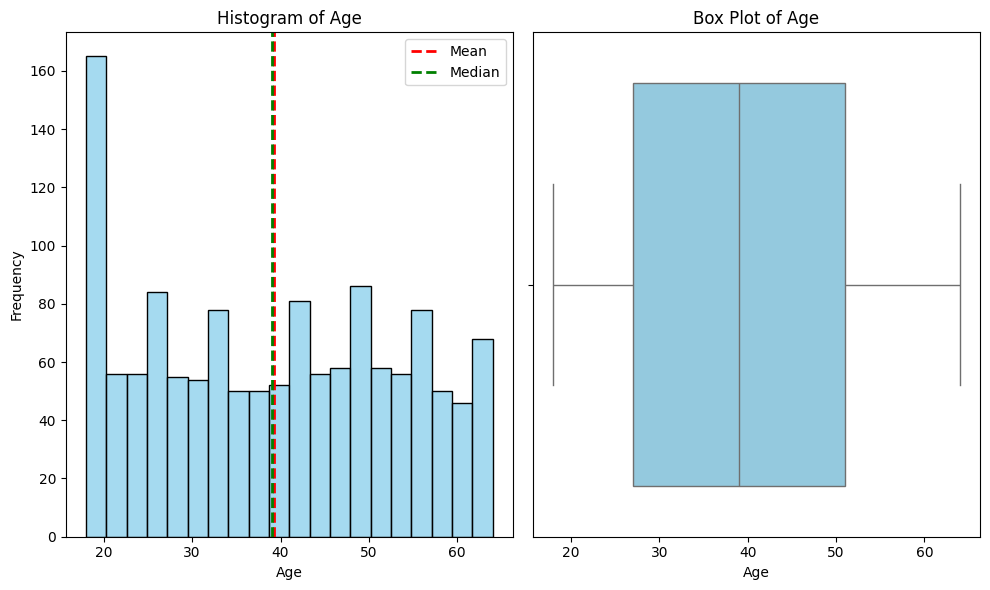

In [14]:
plt.figure(figsize=(10, 6))

#histogram for age
plt.subplot(1, 2, 1)
sns.histplot(df_copy['age'], kde=False, bins = 20, color='skyblue')
plt.axvline(df_copy['age'].mean(), color='red', linestyle='dashed', linewidth=2, label='Mean')
plt.axvline(df_copy['age'].median(), color='green', linestyle='dashed', linewidth=2, label='Median')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Histogram of Age')
plt.legend()

#box plot for age
plt.subplot(1, 2, 2)
sns.boxplot(x=df_copy['age'], color='skyblue')
plt.xlabel('Age')
plt.title('Box Plot of Age')

plt.tight_layout()
plt.show()


**Observation**
*   Histogram
  *   The distribution appears fairly uniform, with no strong skew.
  *   There's a noticeable spike around age 18-19, suggesting a high number of young adults in the dataset.
  *   The mean (red dashed line) and median (green dotted line) are almost overlapping, around age 39, indicating the data is symmetrically distributed.
  *   There is no significant skew to the left or right.
*   Boxplot
  *   The interquartile range (IQR) shows that 50% of the values lie between approximately 27 and 51 years.
  *   There are no outliers in the age data.
  *   The median age (middle line in the box) is around 39, consistent with the histogram.

### bmi

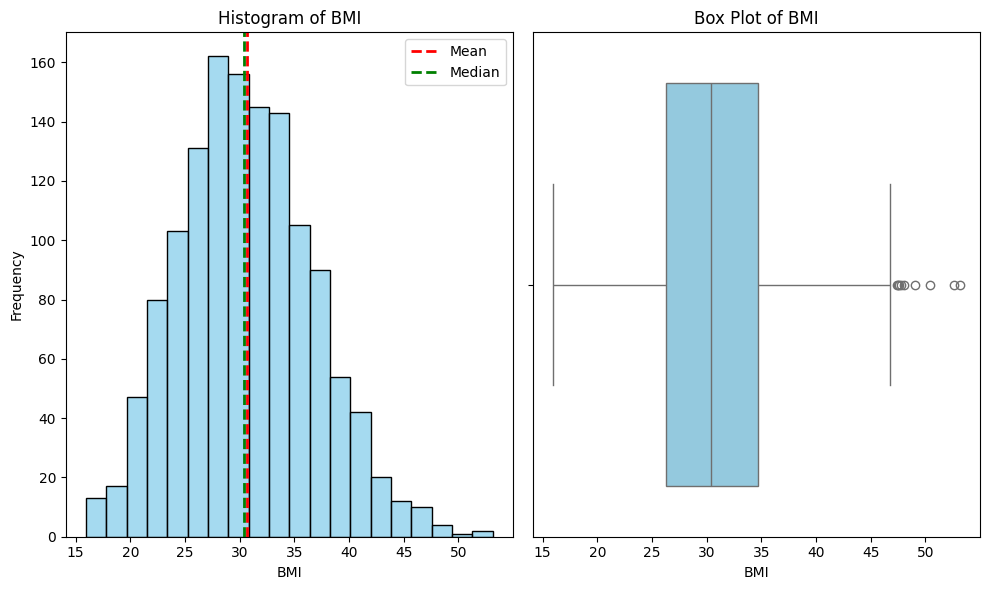

In [15]:
plt.figure(figsize=(10, 6))

#histogram for bmi
plt.subplot(1, 2, 1)
sns.histplot(df_copy['bmi'], kde=False, bins = 20, color='skyblue')
plt.axvline(df_copy['bmi'].mean(), color='red', linestyle='dashed', linewidth=2, label='Mean')
plt.axvline(df_copy['bmi'].median(), color='green', linestyle='dashed', linewidth=2, label='Median')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.title('Histogram of BMI')
plt.legend()

#box plot for bmi
plt.subplot(1, 2, 2)
sns.boxplot(x=df_copy['bmi'], color='skyblue')
plt.xlabel('BMI')
plt.title('Box Plot of BMI')

plt.tight_layout()
plt.show()

**Observation**
*   Histogram
  *   The distribution of BMI is approximately normal (bell-shaped), centered around 30.
  *   Mean and median are almost identical and located in the center, indicating the data is symmetrically distributed.
  *   Majority of individuals have BMI values between 25 and 35, suggesting many are overweight by medical standards.
*   Boxplot
  *   The IQR (box) lies between approximately 26 and 34.
  *   There are several outliers on the higher end (BMI > 45), indicating a few individuals with obese/extreme BMI values.
  *   The distribution is slightly right-skewed (more extreme values on the right), which is confirmed by the outliers.

### children

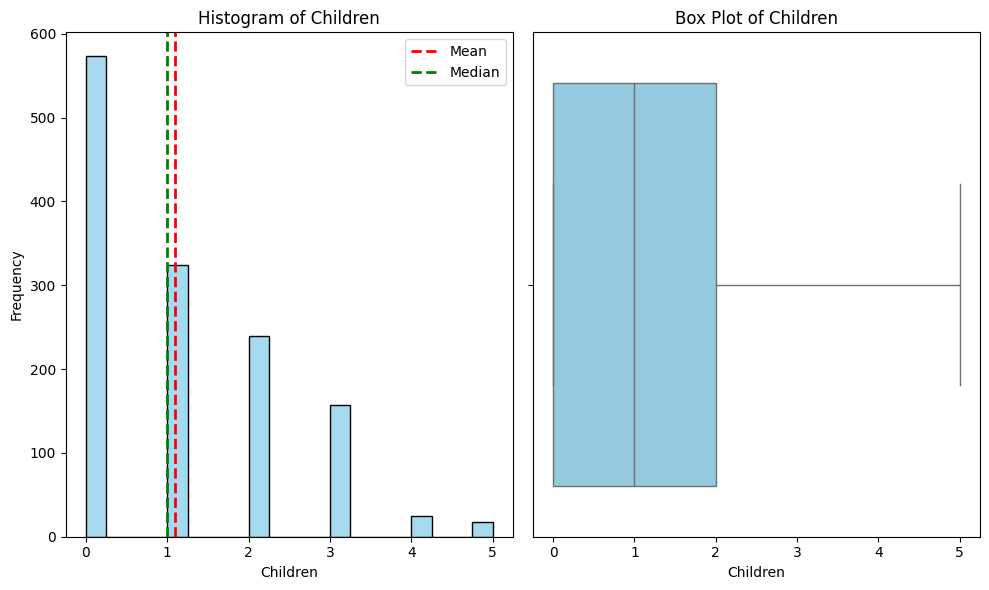

In [16]:
plt.figure(figsize=(10, 6))

#histogram for children
plt.subplot(1, 2, 1)
sns.histplot(df_copy['children'], kde=False, bins = 20, color='skyblue')
plt.axvline(df_copy['children'].mean(), color='red', linestyle='dashed', linewidth=2, label='Mean')
plt.axvline(df_copy['children'].median(), color='green', linestyle='dashed', linewidth=2, label='Median')
plt.xlabel('Children')
plt.ylabel('Frequency')
plt.title('Histogram of Children')
plt.legend()

#box plot for children
plt.subplot(1, 2, 2)
sns.boxplot(x=df_copy['children'], color='skyblue')
plt.xlabel('Children')
plt.title('Box Plot of Children')

plt.tight_layout()
plt.show()

**Observation**
*   Histogram
  *   The distribution is right-skewed, with a large concentration at 0 children.
  *   Most individuals have 0 or 1 child, with counts dropping significantly after that.
  *  There are very few instances of people with 4 or 5 children.
  *  The mean (approx 1.2) is slightly greater than the median (1), which is expected due to the skewness.


*   Boxplot
  *   The boxplot confirms the right-skew — the whiskers extend farther on the right.
  *   No formal outliers are shown since values >3 are still within a whisker’s length.
  *   The data is discrete, and the median is at 1.

### Create a pairwise scatter plot and write your observations. Check relationship between dependent and independent variables. Draw a trendline for each scatter plot.

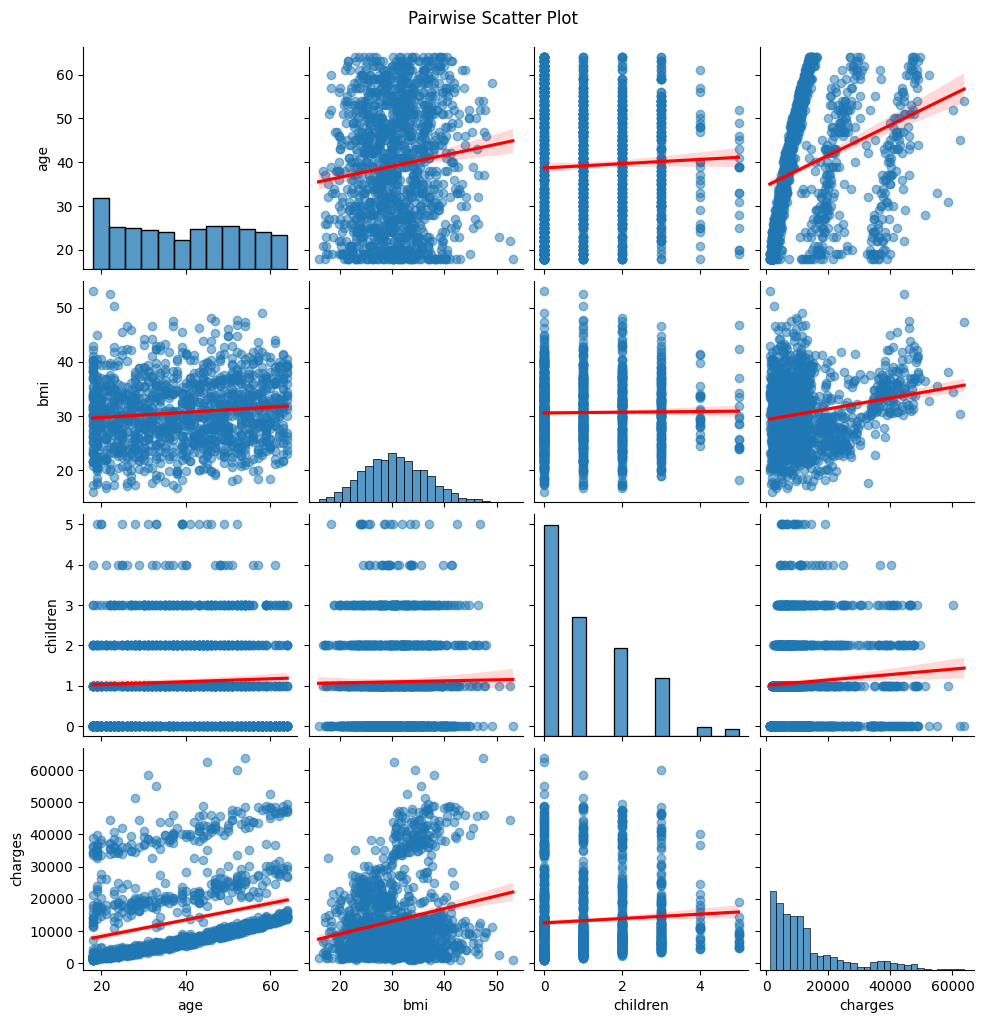

In [17]:
#selecting numeric varibale inclusing the target varibale
selected_columns = ['age', 'bmi', 'children', 'charges']

#pairwise scatter plot
sns.pairplot(df_copy[selected_columns],kind='reg',plot_kws={'line_kws':{'color':'red'}, 'scatter_kws': {'alpha': 0.5}})
plt.suptitle('Pairwise Scatter Plot', y=1.02)
plt.show()

**Observation**
*   age vs charges
  *   Clear positive linear trend: as age increases, charges tend to rise.
  *   Especially visible in older individuals — likely due to more health issues with age.
  *   The regression line confirms this upward relationship.
*   bmi vs charges
  *   Shows a mild upward trend overall.
  *   However, there's a cluster of high charges at higher BMI values — possibly those who are obese and/or smokers.
  *   Indicates that BMI alone doesn't fully explain variation in charges but may be important in combination with other variables.
*   children vs charges
  *   No strong linear trend.
  *   Individuals with 0 to 5 children have similar spread of charges.
  *   The trendline is almost flat, suggesting weak or no correlation between number of children and insurance charges.
*   Inter-variable relationships (age, bmi, children)
  *   age and bmi seem uncorrelated — their scatter is random.
  *   children is a discrete variable, so its scatter plots appear in vertical stripes.
  *   No multicollinearity issues spotted visually among independent variables.

### Create a heatmap to check which variables are highly correlated to each other. Drop the variables if the correlation coeefficent shows high correlation

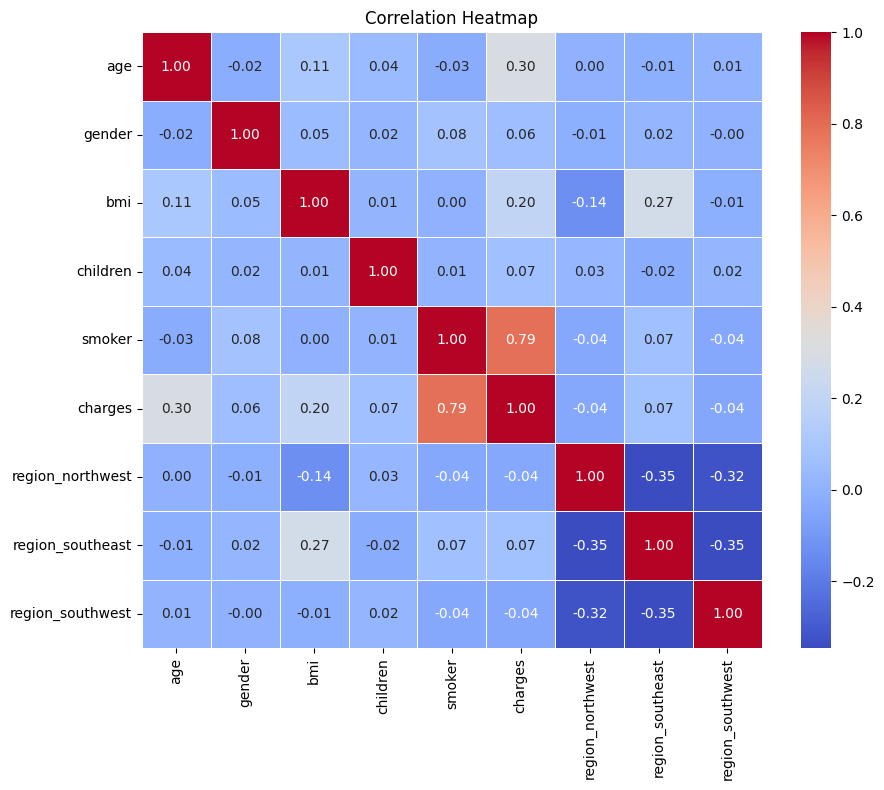

In [18]:
#correlation matrix
correlation_matrix = df_copy.corr()

#heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

**Observation**
*   No independent variables are highly correlated with each other (i.e., no multicollinearity issues).
*   We do NOT need to drop any variables based on correlation.

## Linear Regression Model Building

### Define independent and dependent variables

In [19]:
#defining depenedent(target) varibale
y = df_copy['charges']

#defining independent variables
X = df_copy.drop('charges', axis=1)

print(f"Independent variables shape: {X.shape}")
print(f"Dependent variable shape: {y.shape}")

Independent variables shape: (1337, 8)
Dependent variable shape: (1337,)


### Create dummy variables

In [20]:
#already done while calculating Variance Inflation Factor (VIF)

### Split the data into train and test

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (1069, 8)
Shape of X_test: (268, 8)
Shape of y_train: (1069,)
Shape of y_test: (268,)


### Fit a multiple linear regression by using all variables in the dataset.

In [22]:
#creating the model
model = LinearRegression()

#fitting the model
model.fit(X_train, y_train)

LinearRegression()

### Display regression coefficients and write your observations.

In [23]:
Coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_})
print(f"Intercept: {model.intercept_}")
print(f"Regression coefficients:\n{Coefficients}")

Intercept: -11092.652295945947
Regression coefficients:
            Feature   Coefficient
0               age    248.210720
1            gender   -101.542054
2               bmi    318.701441
3          children    533.009989
4            smoker  23077.764593
5  region_northwest   -391.761455
6  region_southeast   -838.919616
7  region_southwest   -659.139752


**Observation**
*   Intercept = -11,092.65
  *   Base charge when all variables are zero (not directly interpretable in practice)
*   Age = +248.21
  *   For every additional year of age, charges increase by `$248.21`, holding other factors constant.
*   Gender = -101.54
  *   Males pay about `$101.54` less than females, but this effect is small (could be statistically insignificant).
*   BMI = +318.70
  *   Each unit increase in BMI increases charges by `$318.70`, indicating a moderate positive impact.
*   Children = +533.01
  *   Each additional child increases charges by about `$533`, though the effect is modest.
*   Smoker = +23,077.76
  *   Being a smoker increases charges by a huge amount `~$23K`, showing it's the most impactful feature.
*   Region_Northwest = -391.76
  *   People in the northwest pay about `$391.76` less than those in the northeast (baseline).
*   Region_Southeast = -838.92
  *   Southeast residents pay about `$838.92` less than northeast residents.
*   Region_Southwest = -659.14
  *   Southwest residents pay about `$659.14` less than northeast residents  

### Model performance check and write your observations - Calcute R^2 and MSE.


In [24]:
#predict on test data
y_pred = model.predict(X_test)

#calculating R^2
r2 = r2_score(y_test, y_pred)

#calculating MSE
mse = mean_squared_error(y_test, y_pred)

print(f"R^2: {r2}")
print(f"MSE: {mse}")

R^2: 0.8069287081198013
MSE: 35478020.67523558


**Observation**
*   R^2 = 0.807
  *   This means that 80.7% of the variability in insurance charges is explained by your regression model.
  *   This is a strong result, indicating that your model captures the key patterns and relationships in the data very well.
*   Mean Squared Error (MSE): 35,478,020.68
  *   While the MSE value may look large, keep in mind that insurance charges range from $1,000 to $60,000+, so this level of error is reasonable.
  *   This number represents the average squared difference between actual and predicted charges — some large prediction errors are expected due to the wide range of charges and possible outliers.

### Write your Conclusions


**Conclusion**
*   Our linear regression model performs well, with a high R² and a manageable MSE.
*   Key Predictors Identified:
  *   Smoker status is by far the most impactful variable, increasing charges by over $23,000 on average.
  *   Age and BMI also significantly affect charges, with older and higher-BMI individuals paying more.
  *   Gender and number of children have minimal impact on charges.
  *   Region has a minor effect, with individuals from the northeast paying slightly more on average than others.
*   Data Analysis Insights:
  *   The dataset contains no missing values or significant multicollinearity issues.
  *   All variables were appropriately encoded, and the data was clean and well-distributed.
  *   The heatmap and scatter plots confirmed key relationships between features and charges.
*   Business Implication:
  *   This model can help insurance companies estimate premiums or identify high-risk applicants (especially smokers and high-BMI individuals).
  *   It may also guide personal wellness programs to reduce risk factors and lower costs.

### Check Linear Regression assumptions

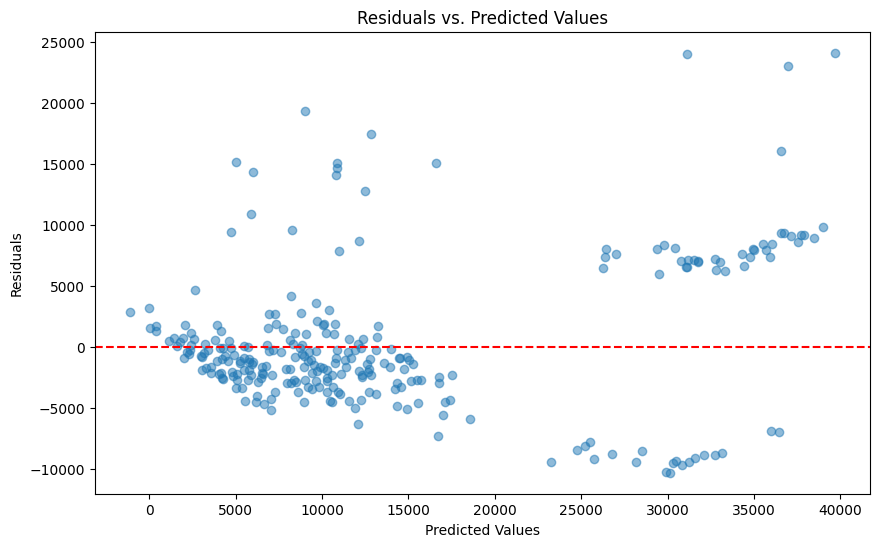

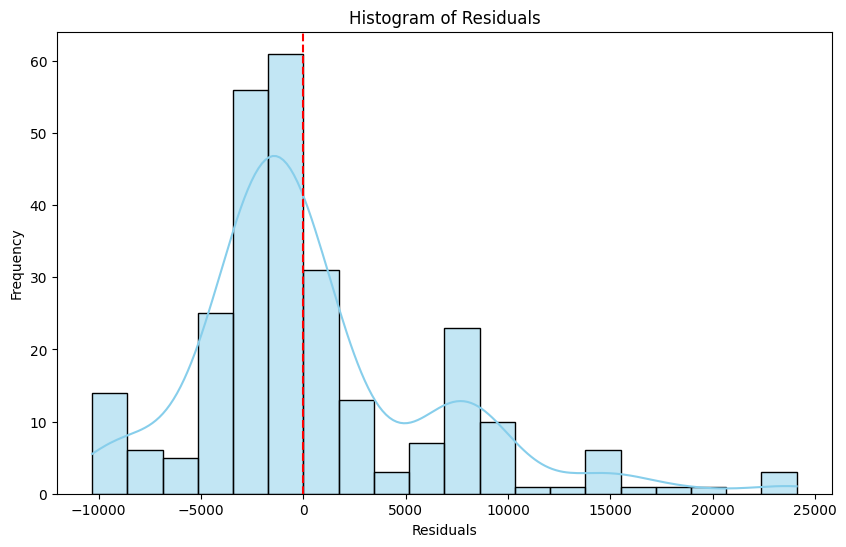

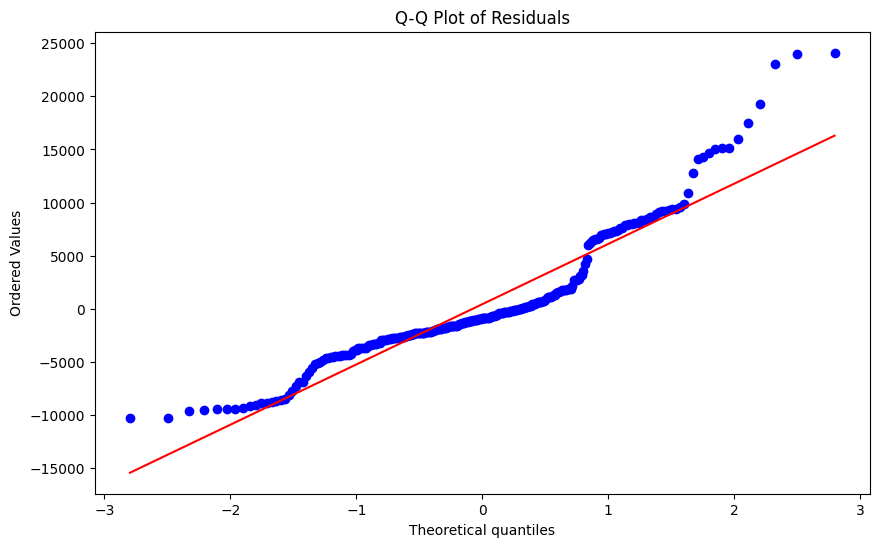

In [25]:
#predicting and calculating residuals
y_pred = model.predict(X_test)
residuals = y_test - y_pred

#scatter plot of residuals vs. predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Predicted Values')
plt.show()

#normality of residuals(Histogram)
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=20, color='skyblue')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals')
plt.show()

#normality of residuals(Q-Q plot)
plt.figure(figsize=(10, 6))
stats.probplot(residuals, plot=plt)
plt.title('Q-Q Plot of Residuals')
plt.show()


**Checking linear regression assumptions**
*   Linearity
  *   Plot: Residuals vs. Predicted Values
      *   There is a slight curve, but no strong nonlinear pattern.
      *   Some heterogeneity in spread at higher prediction values, but overall, the relationship between predicted and actual values appears roughly linear.
*   Homoscedasticity (Equal Variance of Residuals)
  *   Plot: Residuals vs. Predicted Values
      *   The spread of residuals increases with larger predicted values, indicating some heteroscedasticity.
      *   This assumption is Partially met. Residuals spread more for higher predictions
*   Normality of Residuals
  *   Plot: Histogram + Q-Q Plot
      *   Looks roughly bell-shaped, centered at 0, though with some right skew.
      *   Residuals are approximately normal, but with some skew and heavy tails. Not perfect, but acceptable for large samples.
*   Independence of Errors
  *   We did not run the Durbin-Watson test, but since this is not time-series data, it's usually assumed.
  *   Independence of residuals is likely satisfied.
*   No Multicollinearity
  *   Already checked earlier via VIF — all values were below 2.
  *   This assumption is fully satisfied.